# Heat-Pump Sensitivity Paper — Results Notebook

Reproduces and displays **every figure and table** in the paper
*Estimating aggregated heat-pump installed capacity, energy and flexibility from
LV net load and ambient temperature* (`paper/hp_sensitivity_v5.tex`).

This notebook runs in **cached mode**: it displays the artifacts already built in
`paper/figures/` and `paper/tables/`. No heavy cloud pulls (ResStock / NEEA / WPuQ)
run here. Regeneration lives in the last section, behind a `REGENERATE` switch.

Two project modules back this notebook (both in `scripts/`):
- **`utils`** — fitting primitives, data loaders and the figure/table **display**
  helpers (`show_fig`, `show_table`).
- **`outputs`** — one function per paper figure/table that rebuilds it from source.

Layout after the 2026 reorganization: `scripts/` holds the code, `paper/figures`
& `paper/tables` the artifacts shown below, `OLD/` the retired scripts/notebooks.


In [1]:
import os, sys
# locate repo root (folder holding paper/ and scripts/)
_root = os.getcwd()
while not os.path.isdir(os.path.join(_root, 'paper')) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root)
for _p in ('scripts', 'src'):
    _ap = os.path.abspath(_p)
    if _ap not in sys.path:
        sys.path.insert(0, _ap)

import utils as U          # fitters, loaders, show_fig / show_table
import outputs as O        # one generator per figure/table
print('repo root :', _root)
print('figures   :', len(os.listdir('paper/figures')), '| tables:', len(os.listdir('paper/tables')))

repo root : C:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM
figures   : 38 | tables: 6


## 1 · Net-load bathtub model (§II-A)

The aggregate net load is fit as a temperature **bathtub**:
$P_{net}(T)=P_{base}+s_h\max(0,T_h-T)+s_c\max(0,T-T_c)$ — a flat base load with a
heating arm below $T_h$ and a cooling arm above $T_c$. Unsupervised: net load and
temperature only.

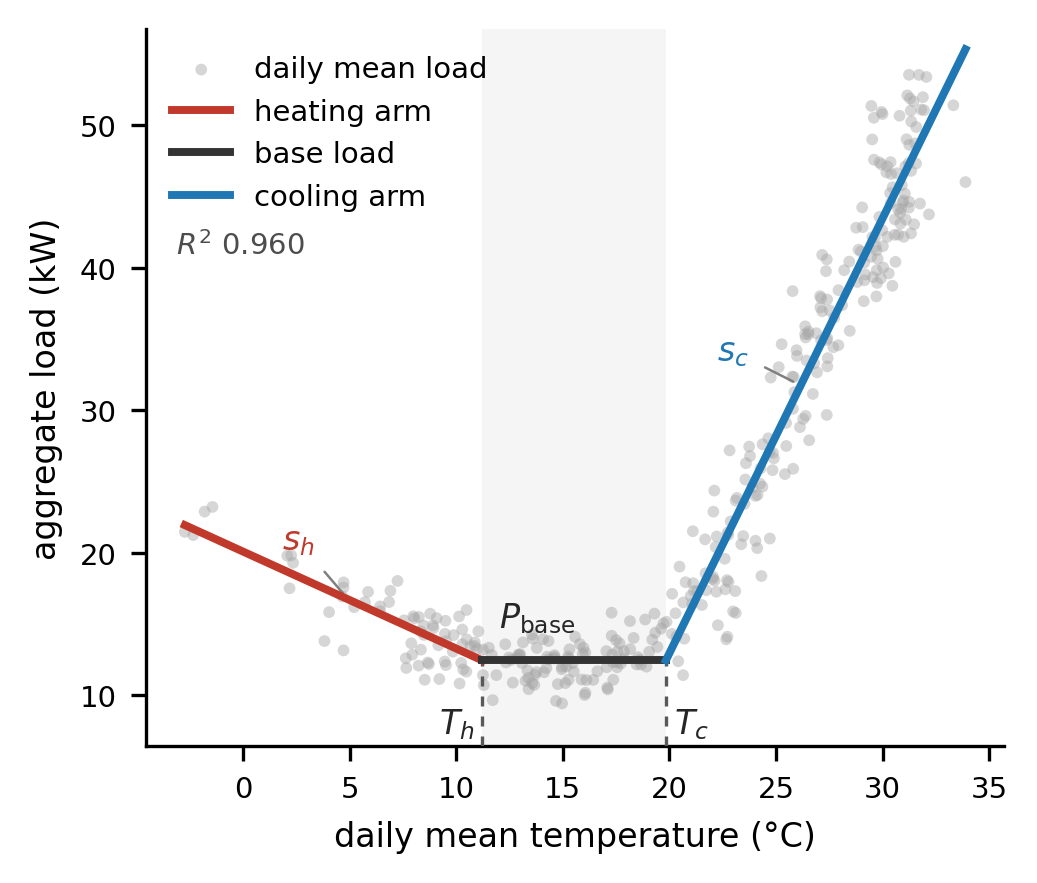

*Fig. 2 — Austin bathtub fit with the terms of Eq. (1). O.fig_bathtub_example()*

In [2]:
U.show_fig('fig_bathtub_example', caption='Fig. 2 — Austin bathtub fit with the terms of Eq. (1). O.fig_bathtub_example()')

Extending the arms to where the aggregate would draw its full per-mode installed
capacity (SF→1) defines the critical temperatures and splits the domain into
regions **R1–R5**.

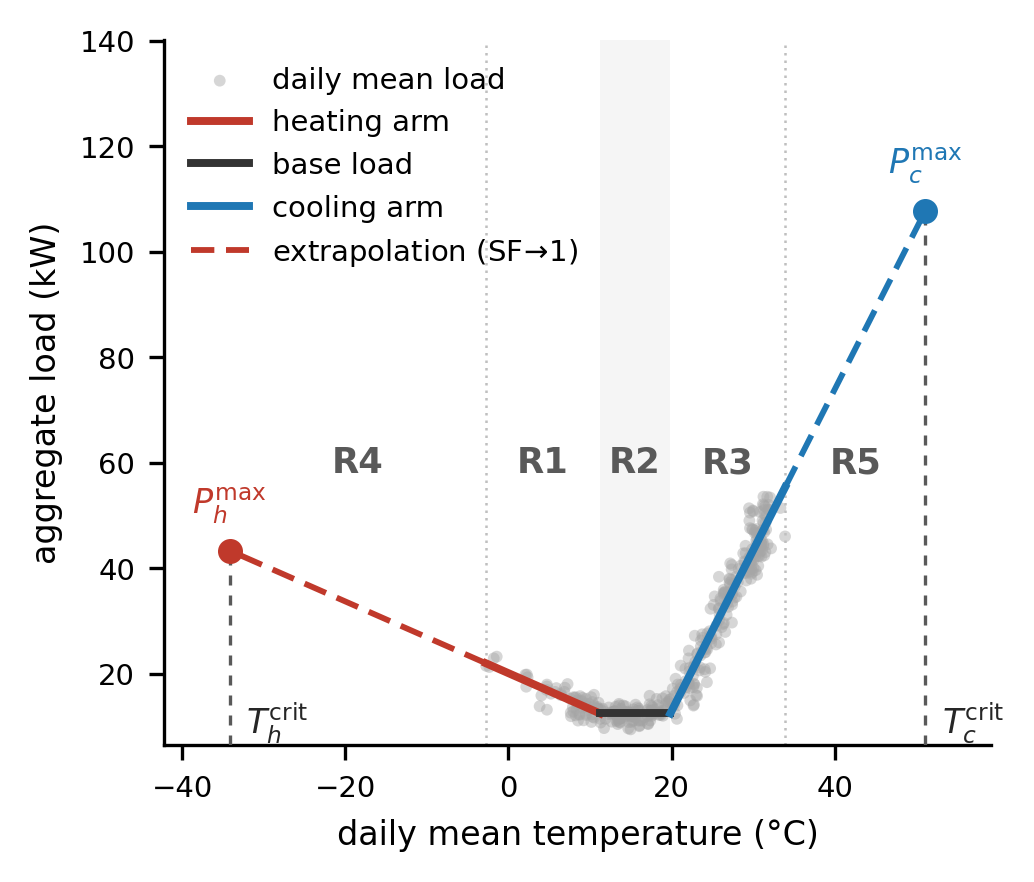

*Fig. 4 — Arms extrapolated to SF→1, regions R1–R5. O.fig_bathtub_critical()*

In [3]:
U.show_fig('fig_bathtub_critical', caption='Fig. 4 — Arms extrapolated to SF→1, regions R1–R5. O.fig_bathtub_critical()')

## 2 · Simultaneity-factor function (§II-B)

The supervised half. $\mathrm{SF}(T)=P_{ETL}(T)/P_{ETL}^{\max}$ is fit as two linear
arms **anchored at the net-load thresholds** and evaluated on the below-threshold
days — a slope $m$ and intercept $b$ per arm that transfer across substations.

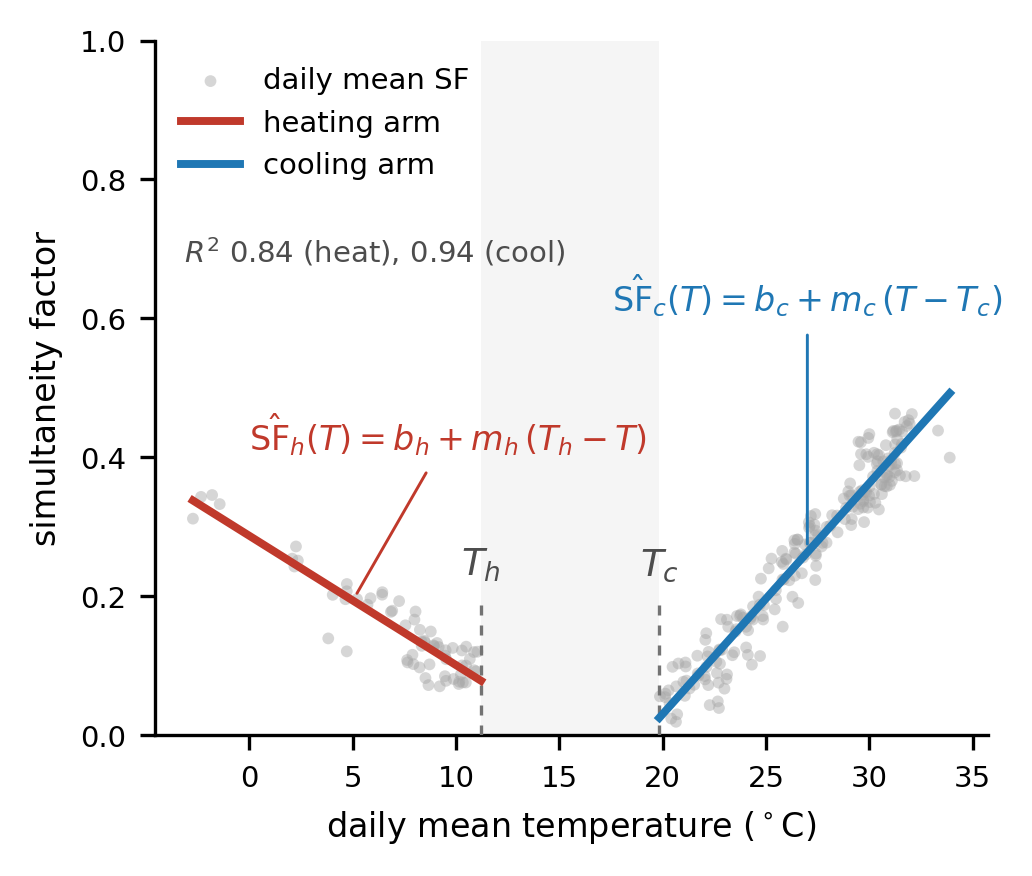

*Fig. 3 — SF arms anchored at the net-load thresholds. O.fig_sf_arms_anchored()*

In [4]:
U.show_fig('fig_sf_arms_anchored', caption='Fig. 3 — SF arms anchored at the net-load thresholds. O.fig_sf_arms_anchored()')

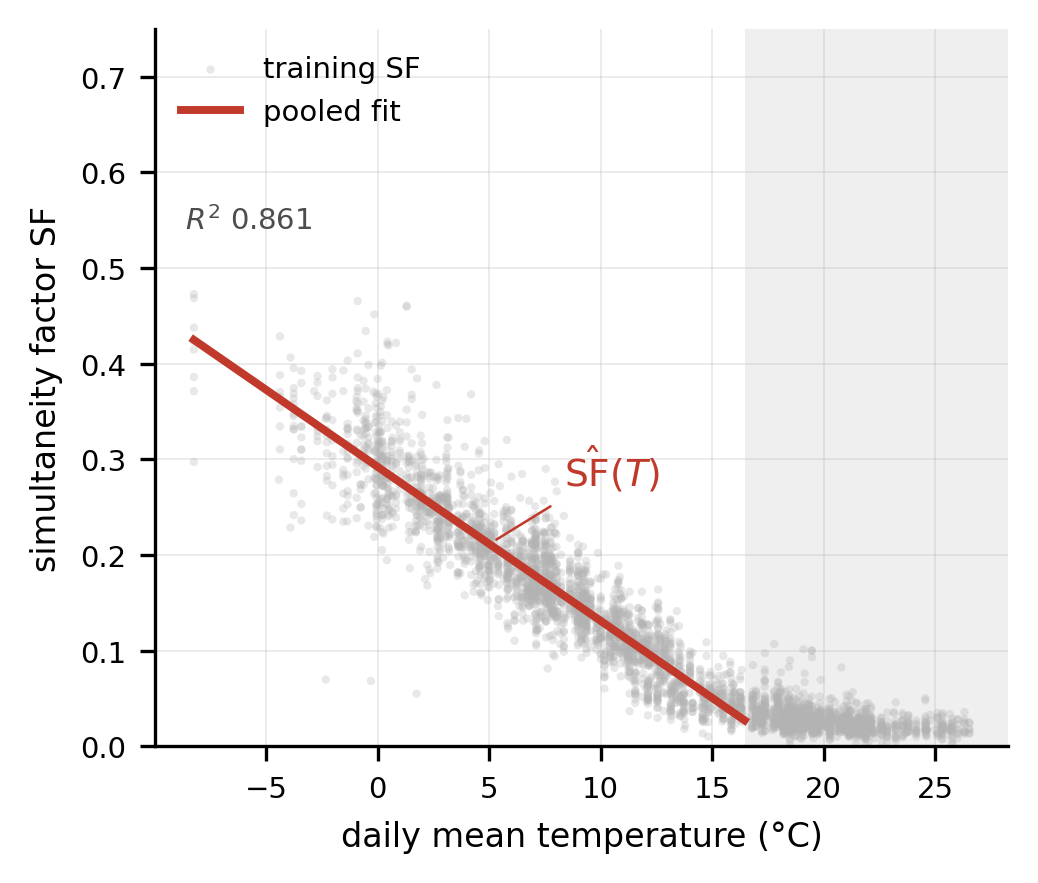

*Pooled SF across the synthetic substations. O.tab_sf()*

In [5]:
U.show_fig('fig_sf_pooled', caption='Pooled SF across the synthetic substations. O.tab_sf()')

Per-substation SF parameters (median, IQR) and the pooled training-set values:

In [6]:
U.show_table('tab_sf')

**tab_sf** — Per-substation fitted SF parameters by number of aggregated HPs N_hp, as a median with its interquartile range

,N_hp,R^2,SF_cold,b,m (°C^-1),T_h^SF (°C)
0,5,0.926,0.42 (0.11),0.018 (0.020),0.015 (0.005),16.8 (1.3)
1,10,0.935,0.42 (0.07),0.019 (0.014),0.016 (0.004),16.8 (1.2)
2,20,0.947,0.43 (0.07),0.025 (0.010),0.016 (0.002),16.5 (0.7)
3,30,0.949,0.42 (0.04),0.023 (0.006),0.016 (0.002),16.6 (0.6)
4,40,0.948,0.42 (0.04),0.025 (0.006),0.016 (0.002),16.6 (0.5)
5,50,0.949,0.43 (0.03),0.026 (0.004),0.016 (0.001),16.5 (0.3)
6,all,0.946,0.43 (0.06),0.024 (0.008),0.016 (0.002),16.6 (0.6)


,N_hp,R^2,SF_cold,b,m (°C^-1),T_h^SF (°C)
0,5,0.926,0.42 (0.11),0.018 (0.020),0.015 (0.005),16.8 (1.3)
1,10,0.935,0.42 (0.07),0.019 (0.014),0.016 (0.004),16.8 (1.2)
2,20,0.947,0.43 (0.07),0.025 (0.010),0.016 (0.002),16.5 (0.7)
3,30,0.949,0.42 (0.04),0.023 (0.006),0.016 (0.002),16.6 (0.6)
4,40,0.948,0.42 (0.04),0.025 (0.006),0.016 (0.002),16.6 (0.5)
5,50,0.949,0.43 (0.03),0.026 (0.004),0.016 (0.001),16.5 (0.3)
6,all,0.946,0.43 (0.06),0.024 (0.008),0.016 (0.002),16.6 (0.6)


In [7]:
U.show_table('tab_sf_train')

**tab_sf_train** — Total WAPE of the single pooled SF curve against the training substations, by N_hp

,N_hp,total WAPE (%)
0,5,21.0
1,10,15.3
2,20,12.5
3,30,11.6
4,40,11.1
5,50,10.7
6,all,14.9


,N_hp,total WAPE (%)
0,5,21.0
1,10,15.3
2,20,12.5
3,30,11.6
4,40,11.1
5,50,10.7
6,all,14.9


## 3 · Energy and installed-capacity estimation (§III)

ETL **energy** from integrating the fitted arms over the temperature record;
**installed capacity** from the arm slope scaled by the transferred SF.

In [8]:
U.show_table('tab_energy')

**tab_energy** — Energy-estimate accuracy against submetered HP energy, by the resolution of the fit and of the temperature integration

,fit + integration,WAPE (%),median ratio
0,daily + daily,15.3,0.88
1,hourly + hourly,15.4,0.86
2,daily + hourly,12.4,0.92


,fit + integration,WAPE (%),median ratio
0,daily + daily,15.3,0.88
1,hourly + hourly,15.4,0.86
2,daily + hourly,12.4,0.92


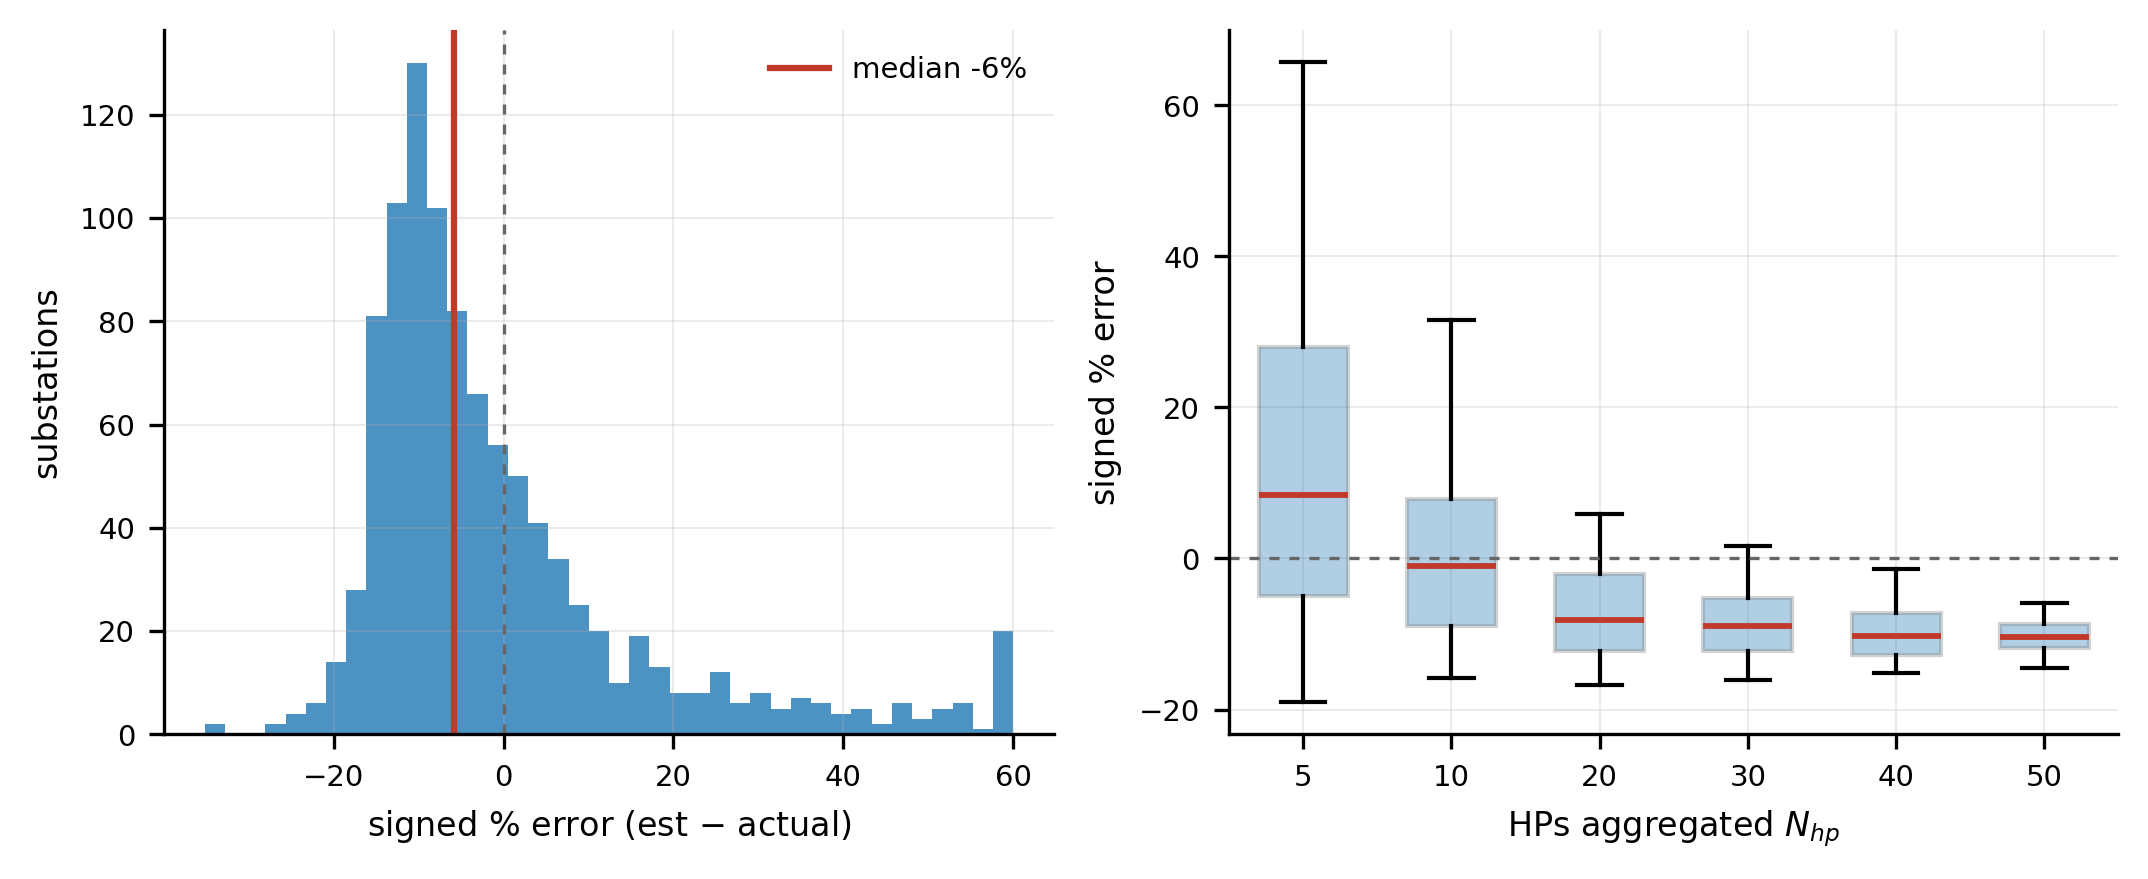

*Energy-estimate error, below-threshold days. O.fig_energy_error(below_th=True)*

In [9]:
U.show_fig('fig_energy_error_belowTh', caption='Energy-estimate error, below-threshold days. O.fig_energy_error(below_th=True)')

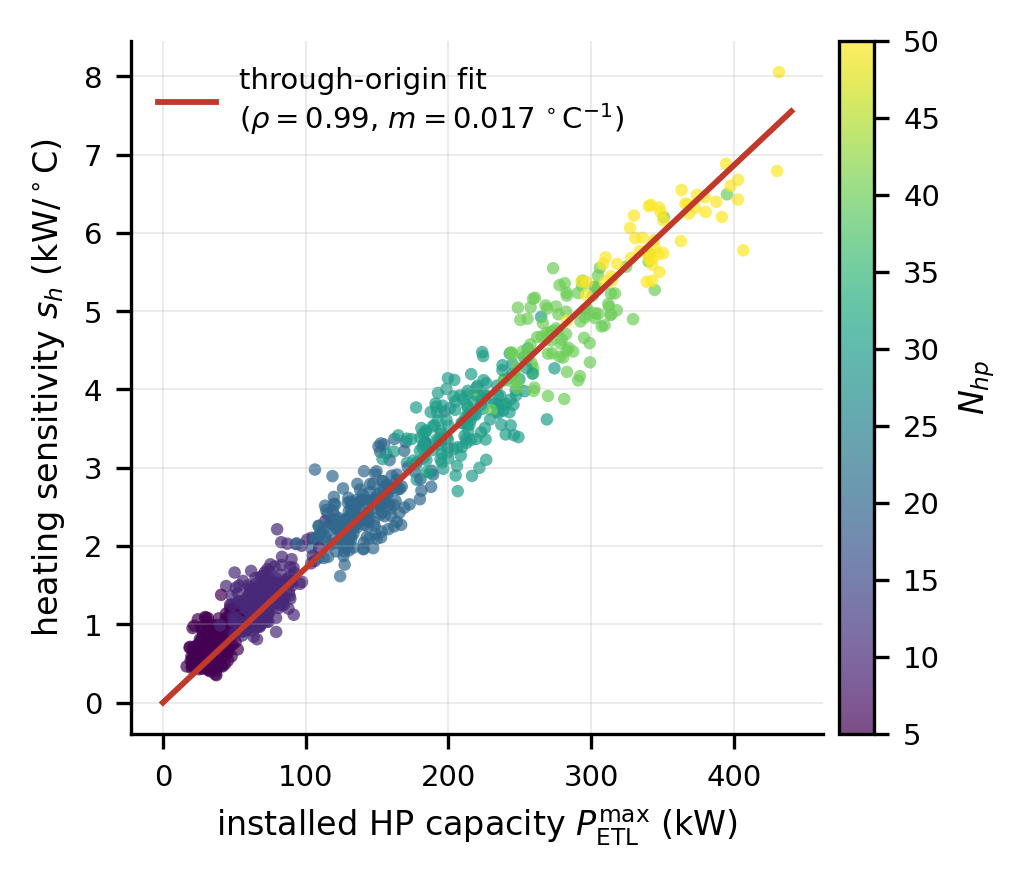

*Installed capacity vs fitted arm slope. O.fig_slope_capacity()*

In [10]:
U.show_fig('fig_slope_capacity', caption='Installed capacity vs fitted arm slope. O.fig_slope_capacity()')

In [11]:
U.show_table('tab_capacity')

**tab_capacity** — Installed-capacity accuracy on the held-out substations for two estimators

,estimator,WAPE (%),median ratio,R^2
0,"Eq. , transferred SF",10.3,1.06,0.969
1,oracle (own SF),6.2,1.03,0.986


,estimator,WAPE (%),median ratio,R^2
0,"Eq. , transferred SF",10.3,1.06,0.969
1,oracle (own SF),6.2,1.03,0.986


## 4 · Flexibility potential (§IV)

The SF turns the fitted load into a flexibility envelope: how much ETL power can be
shifted, when, and across the season.

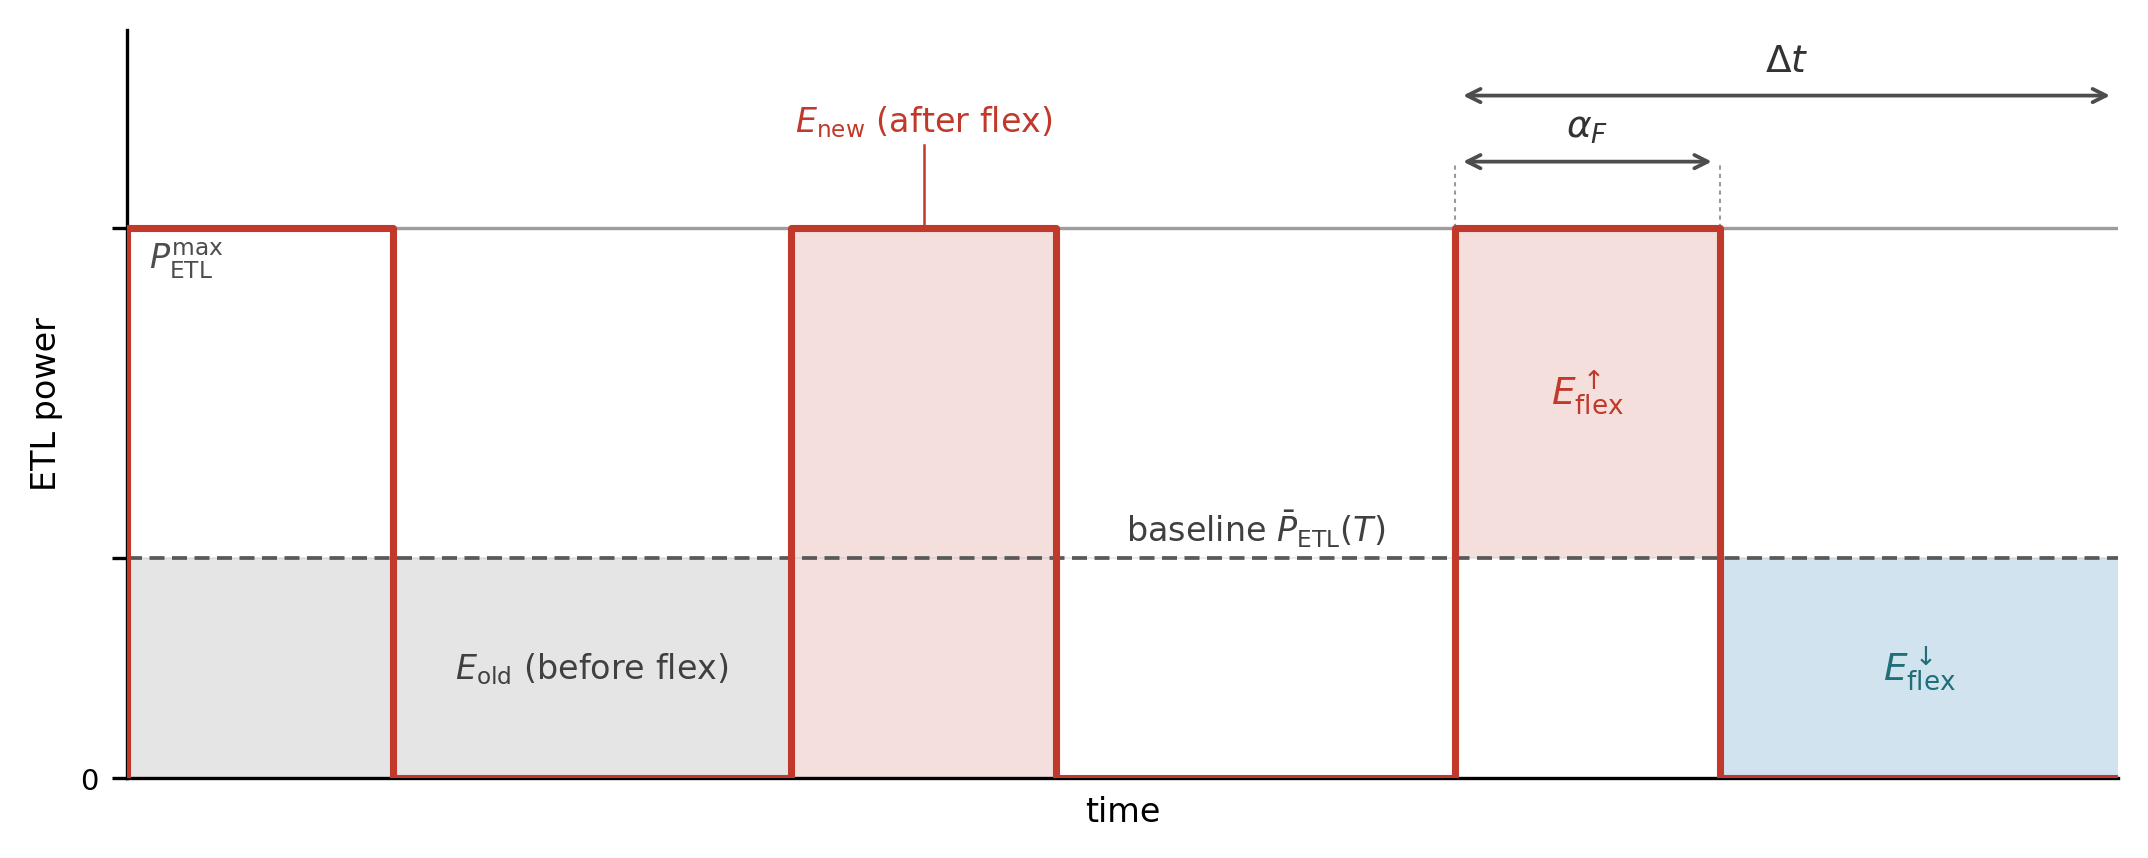

*Flexibility schedule / envelope. O.fig_flex_schedule()*

In [12]:
U.show_fig('fig_flex_schedule', caption='Flexibility schedule / envelope. O.fig_flex_schedule()')

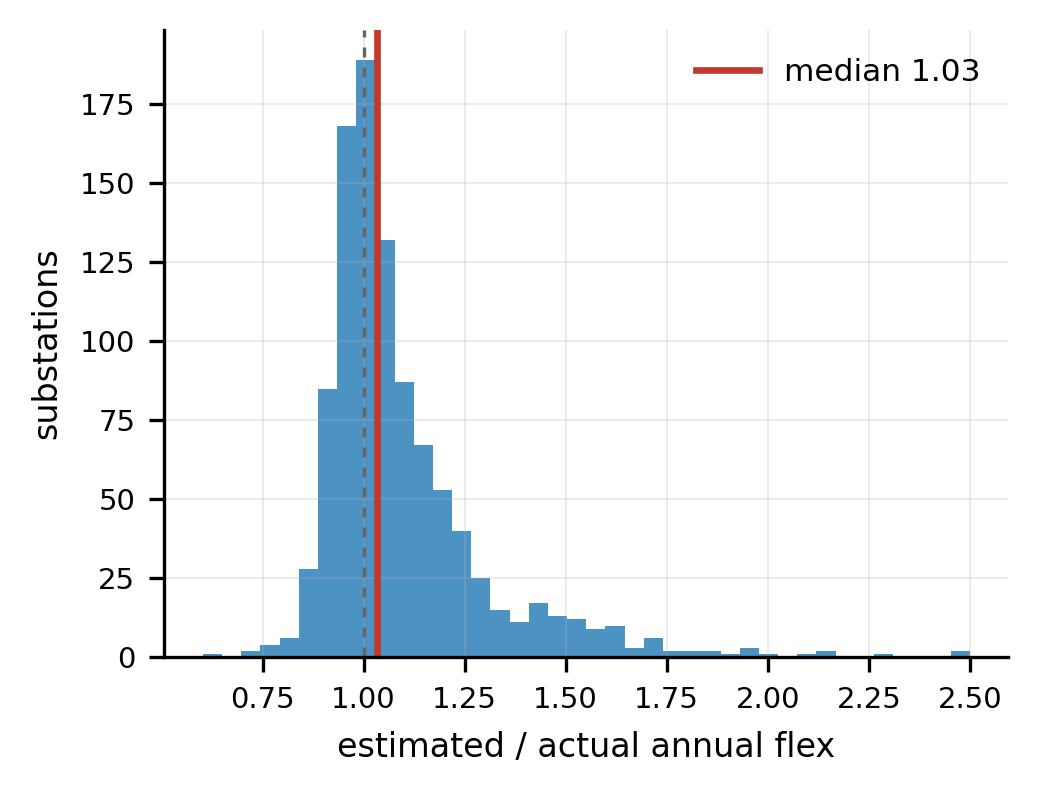

*Estimated / actual annual flex across substations. O.flex_figures()*

In [13]:
U.show_fig('fig_flex_ratio', caption='Estimated / actual annual flex across substations. O.flex_figures()')

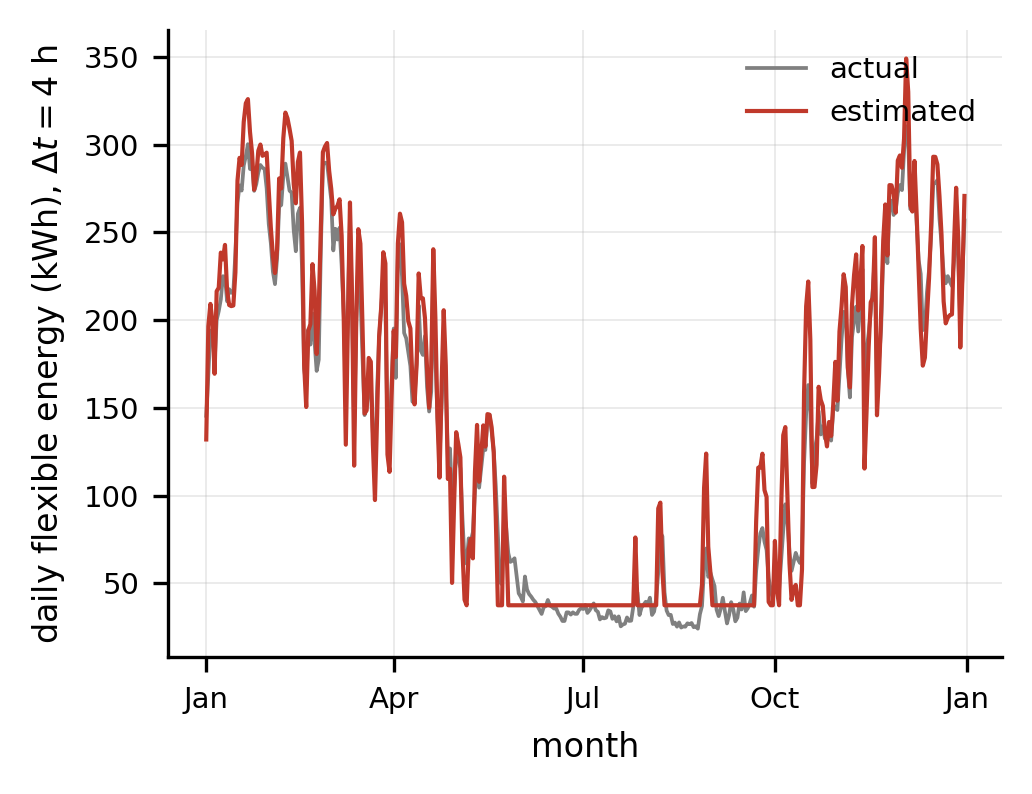

*Seasonal daily flexible energy, estimated vs actual. O.flex_figures()*

In [14]:
U.show_fig('fig_flex_season', caption='Seasonal daily flexible energy, estimated vs actual. O.flex_figures()')

## 5 · Generalisation to a real unseen feeder (§V-G)

The transferred SF is applied to the real German WPuQ feeder, never seen in
training. The feeder's own SF shares the net-load threshold by construction; both
fits are drawn only below $T_h$.

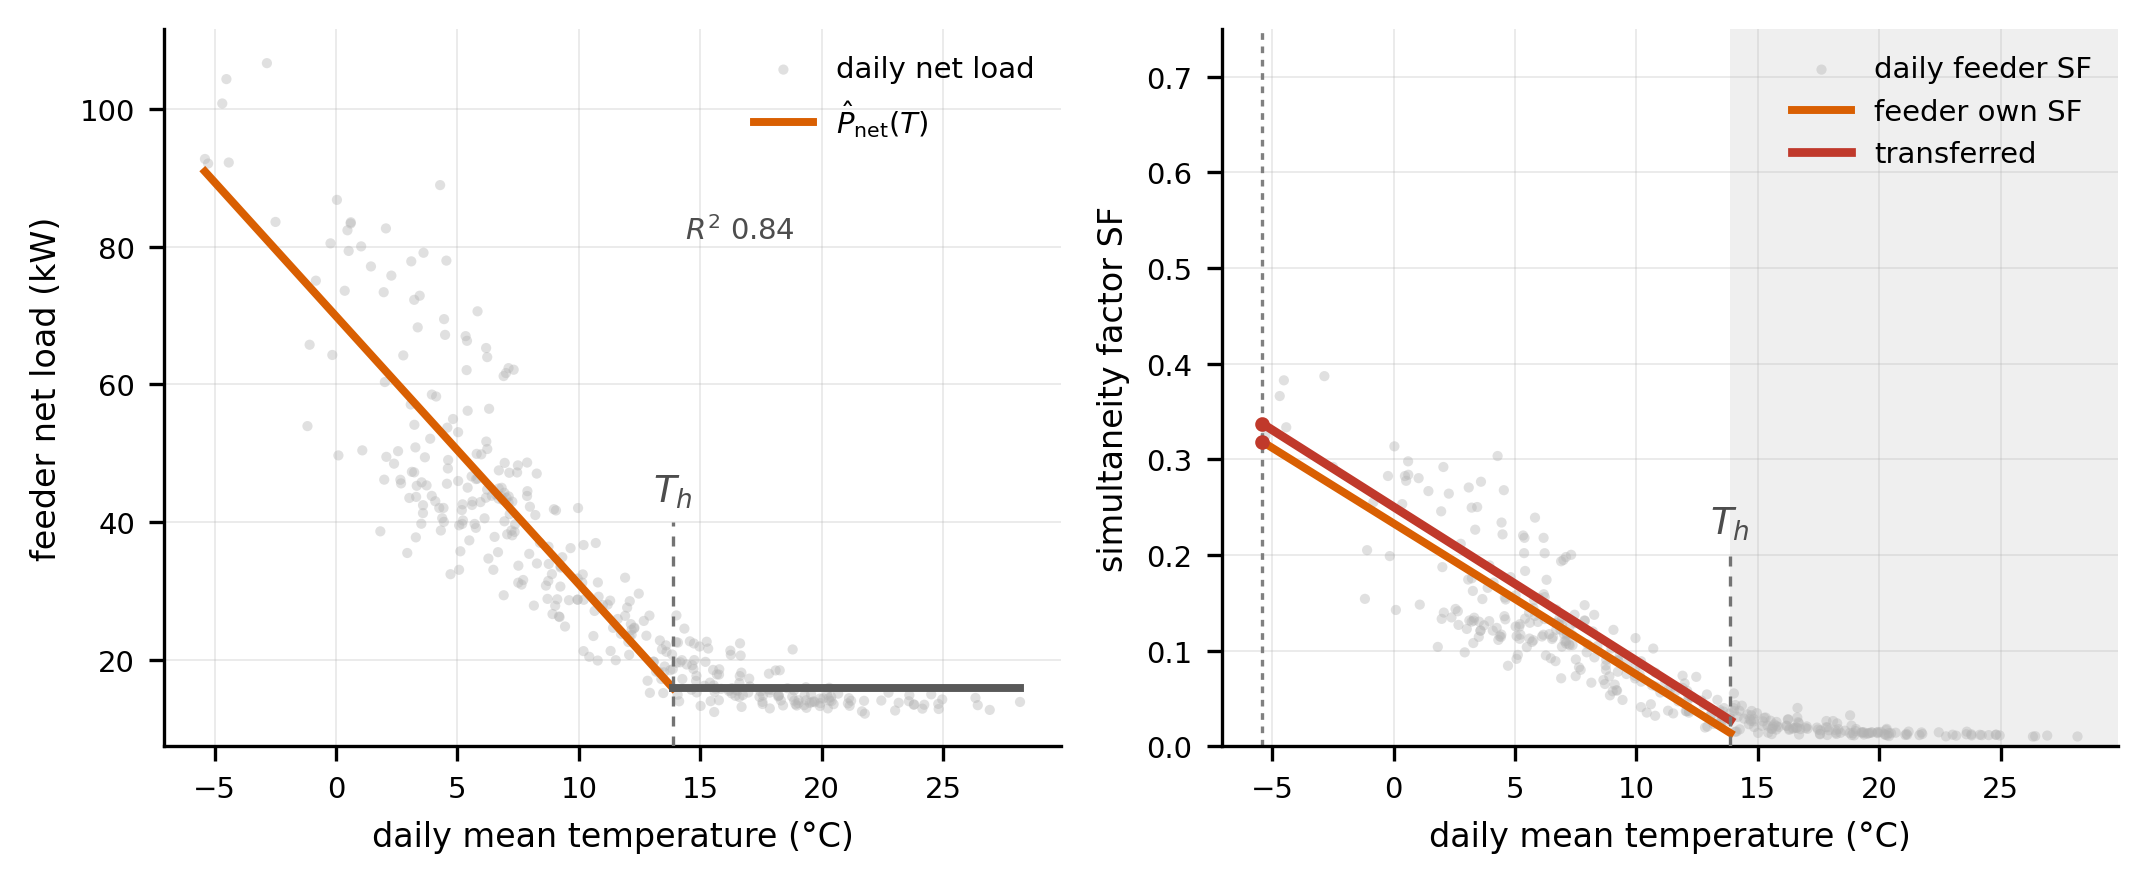

*Fig. 11 — Real feeder: net-load fit (left), feeder-own vs transferred SF (right). O.fig_real_feeder()*

In [15]:
U.show_fig('fig_real_feeder', caption='Fig. 11 — Real feeder: net-load fit (left), feeder-own vs transferred SF (right). O.fig_real_feeder()')

Use-case error as HP circuits are progressively removed (fixed 37-house base):

In [16]:
U.show_table('tab_feeder_sweep')

**tab_feeder_sweep** — Use-case estimates on the real feeder as HP circuits are removed, at a fixed 37-house base. Signed median error over 200 random subsets per count

,N_hp,capacity (%),energy (%)
0,5,+9,+48
1,10,-0,+9
2,15,-4,-2
3,20,-6,-8
4,25,-6,-11
5,30,-7,-14
6,37,-7,-15


,N_hp,capacity (%),energy (%)
0,5,+9,+48
1,10,-0,+9
2,15,-4,-2
3,20,-6,-8
4,25,-6,-11
5,30,-7,-14
6,37,-7,-15


## 6 · Cross-dataset characterization

Fitted bathtub + SF parameters for **eight real aggregated datasets** across three
continents and every temperature regime (Hamelin DE, Kloten CH, Austin US, NEEA
Washington & Oregon, ResStock ASHP Hennepin/King/Maricopa). ResStock ETL heating
includes the electric backup element (compressor + `heating_hp_bkup`), so the
cold-climate heating arm stays monotonic. This is the transferability evidence
behind the SF claim.

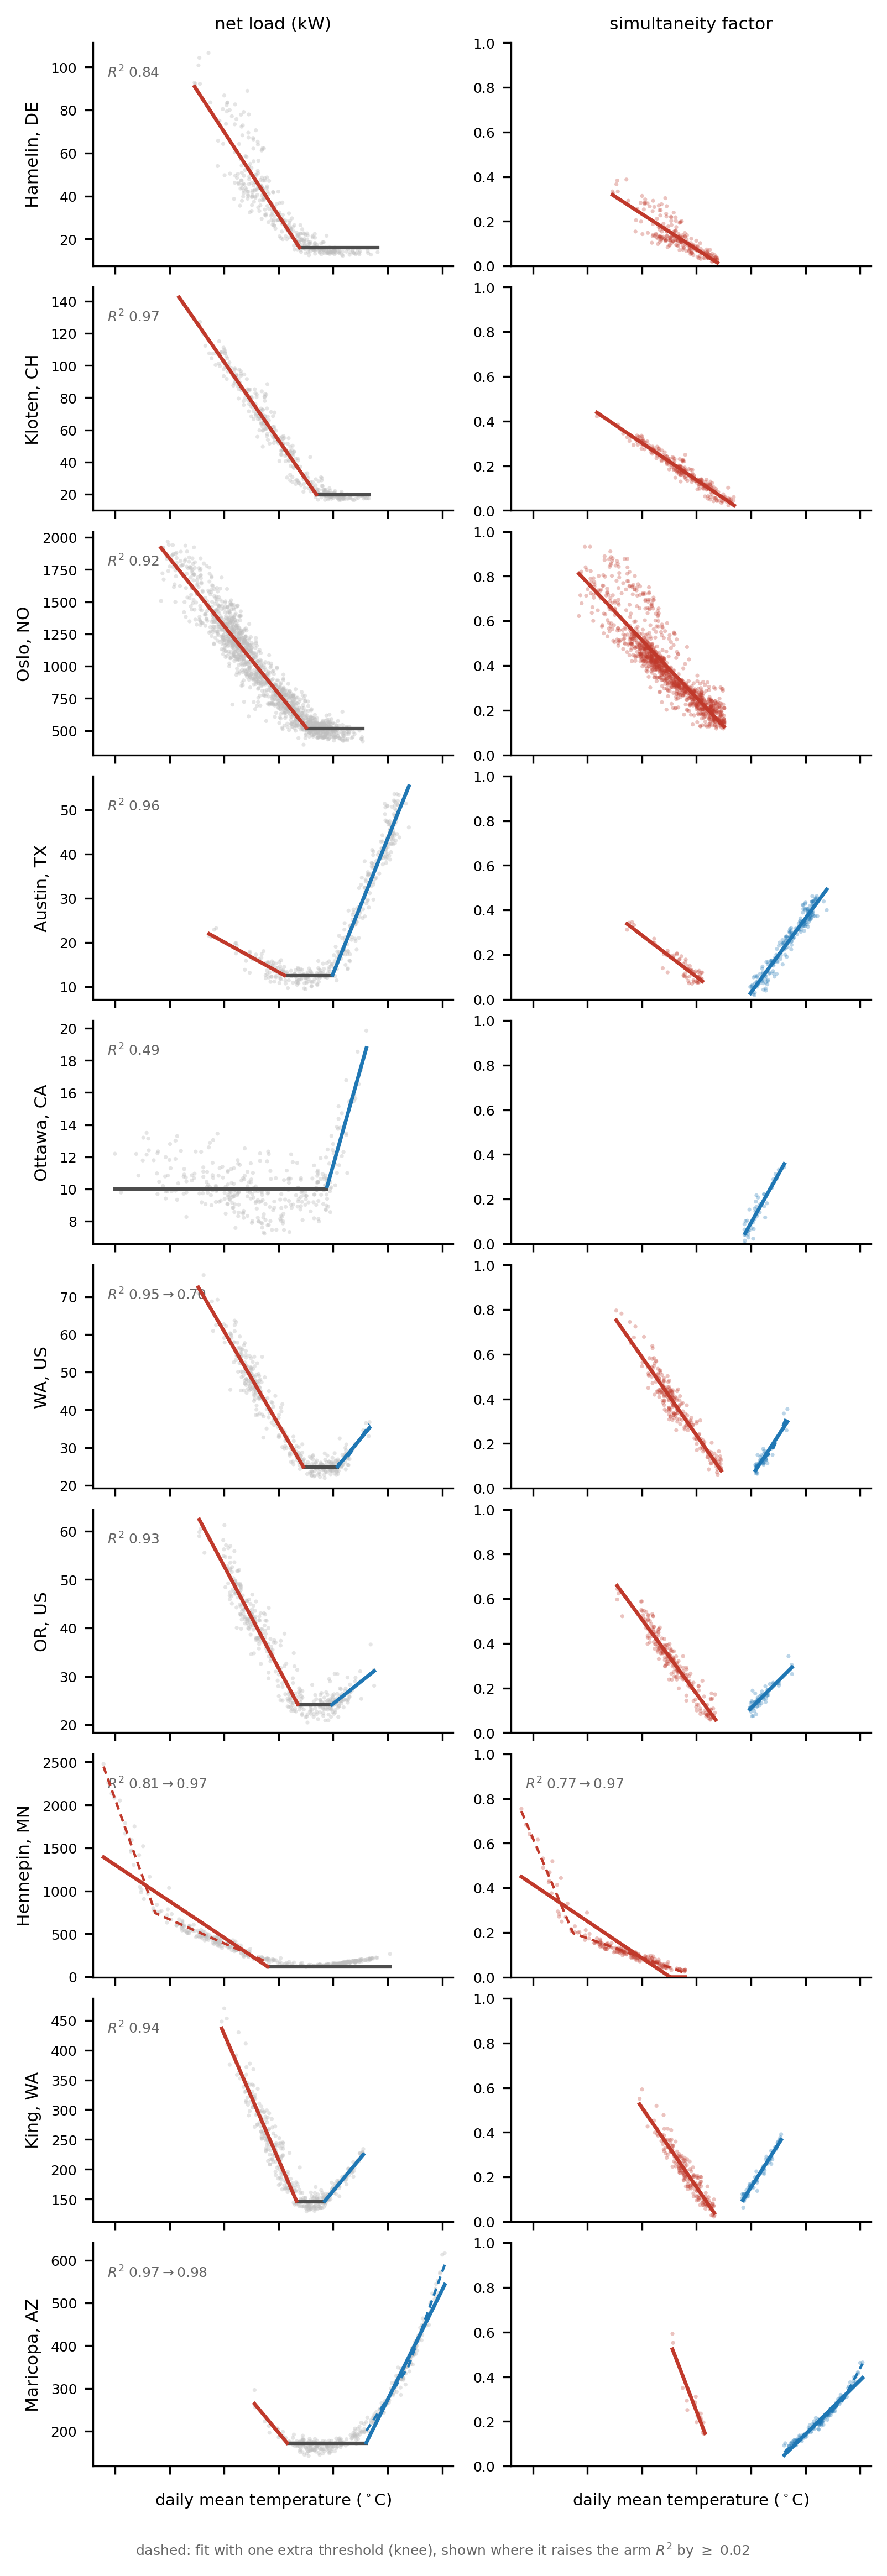

*Per-dataset net-load bathtub (left) and SF (right). O.fig_cross_montage()*

In [17]:
U.show_fig('fig_cross_montage', width=620, caption='Per-dataset net-load bathtub (left) and SF (right). O.fig_cross_montage()')

In [18]:
# Underlying fitted parameters (cached CSVs from the cross-dataset pipeline)
import pandas as pd
cross = pd.read_csv('scratchpad/cross_table.csv')
neea  = pd.read_csv('scratchpad/neea_rows.csv')
cols = ['label','n','mode','days','T_min','T_max','P_base','s_h','T_h','s_c','T_c','R2','m_h','SF_cold','R2_SFh']
pd.concat([cross, neea], ignore_index=True)[cols].round(3)

,label,n,mode,days,T_min,T_max,P_base,s_h,T_h,s_c,T_c,R2,m_h,SF_cold,R2_SFh
0,German WPuQ (real HP),37,heating hockey,365,-5.399,28.166,15.889,3.894,13.871,NaN,NaN,0.841,0.016,0.318,0.716
1,Swiss substation (real HP),50,heating hockey,365,-8.248,26.533,19.675,4.876,16.940,NaN,NaN,0.967,0.017,0.438,0.946
2,Austin Pecan St (real),22,bathtub,365,-2.738,33.892,12.463,0.680,11.203,3.049,19.837,0.960,0.019,0.338,0.839
3,ResStock ASHP -- Hennepin MN (cold),150,heating hockey,366,-22.096,30.429,117.721,42.335,8.000,NaN,NaN,0.808,0.016,0.450,0.770
4,ResStock ASHP -- King WA (mild),150,bathtub,366,-0.426,25.538,145.585,21.108,13.345,11.037,18.366,0.937,0.036,0.526,0.902
5,ResStock ASHP -- Maricopa AZ (hot),150,bathtub,366,5.600,40.465,171.655,15.347,11.616,25.718,26.033,0.975,0.063,0.523,0.861
6,COFACTOR Norway (real HP),849,heating hockey,1462,-11.558,25.446,515.574,52.467,15.190,NaN,NaN,0.924,0.026,0.811,0.802
7,Carleton Ottawa (real AC),12,cooling hockey,334,-20.000,26.100,9.994,NaN,NaN,1.198,18.774,0.491,NaN,NaN,NaN
8,NEEA WA (real HP),23,bathtub,365,-4.708,26.672,24.857,2.473,14.549,1.759,20.777,0.949,0.035,0.753,0.910
9,NEEA OR (real HP),21,bathtub,365,-4.537,27.530,24.123,2.113,13.581,0.901,19.763,0.928,0.033,0.658,0.912


In [19]:
U.show_table('tab_cross')

**tab_cross** — Net-load and SF fit parameters for one aggregate per dataset. n is the number of aggregated consumers; T_\min,T_\max the recorded temperature range [°C]; s_h,s_c [kW/°C]; T_h,T_c [°C]; m_h,m_c [°C^-1]; SF_c/SF_h the coldest-/hottest-day SF. ETL-technology codes: ASHP air-source heat pump; GSHP ground-source heat pump; DHP ductless (mini-split) heat pump; AC air conditioning; ER electric resistance heating.

,,,\multicolumn3c,\multicolumn6cNet-load fit \hatP_net(T),\multicolumn8cSF fit \hatSF(T)


,,,\multicolumn3c,\multicolumn6cNet-load fit \hatP_net(T),\multicolumn8cSF fit \hatSF(T)


## Appendix · Regeneration

Every artifact above is cached. To rebuild from source, set `REGENERATE = True`.
Most generators read local caches and are fast; **`O.build_cross_table(repull=True)`**
re-pulls ~450 ResStock parquets from the NREL S3 bucket (minutes, network-dependent),
so it is left out of the default rebuild — call it explicitly when you want fresh
ResStock rows. Run from the repo root (this notebook already put `scripts/` on the
path).

In [20]:
REGENERATE = False   # flip to True to rebuild every cached artifact

BUILD = [
    ('fig_bathtub_example',        O.fig_bathtub_example),
    ('fig_bathtub_critical',       O.fig_bathtub_critical),
    ('fig_sf_arms_anchored',       O.fig_sf_arms_anchored),
    ('fig_sf_austin_activity',     O.fig_sf_austin_activity),        # v5 SF variant
    ('tab_sf / tab_sf_train / fig_sf_pooled', O.tab_sf),
    ('tab_energy',                 O.tab_energy),
    ('fig_energy_error_belowTh',   lambda: O.fig_energy_error(below_th=True)),
    ('fig_energy_error',           lambda: O.fig_energy_error(below_th=False)),  # v5 variant
    ('fig_slope_capacity',         O.fig_slope_capacity),
    ('tab_capacity',               O.tab_capacity),
    ('fig_flex_schedule',          O.fig_flex_schedule),
    ('fig_flex_ratio / fig_flex_season', O.flex_figures),
    ('fig_real_feeder',            O.fig_real_feeder),
    ('tab_feeder_sweep',           O.tab_feeder_sweep),
    ('neea_rows',                  O.neea_fit),
    ('cross_table (refit, no re-pull)', lambda: O.build_cross_table(repull=False)),
    ('tab_cross',                  O.tab_cross),
    ('fig_cross_montage',          O.fig_cross_montage),
]

if REGENERATE:
    for label, fn in BUILD:
        print('>>>', label, flush=True)
        fn()
    # Heavy, opt-in: fresh ResStock pull (compressor + heating_hp_bkup) then refit
    # O.build_cross_table(repull=True); O.tab_cross(); O.fig_cross_montage()
else:
    print('REGENERATE is False — showing cached artifacts only.')
    for label, _ in BUILD:
        print('  ', label)

REGENERATE is False — showing cached artifacts only.
   fig_bathtub_example
   fig_bathtub_critical
   fig_sf_arms_anchored
   fig_sf_austin_activity
   tab_sf / tab_sf_train / fig_sf_pooled
   tab_energy
   fig_energy_error_belowTh
   fig_energy_error
   fig_slope_capacity
   tab_capacity
   fig_flex_schedule
   fig_flex_ratio / fig_flex_season
   fig_real_feeder
   tab_feeder_sweep
   neea_rows
   cross_table (refit, no re-pull)
   tab_cross
   fig_cross_montage
